# ¿Es el MSE de la primera iteración una cota superior del error?

**Objetivo de este notebook.** En la justificación de por qué se abandonó la normalización
"MSE / MSE de la primera iteración" (ver `docs/21_07_nmse_normalization.md`, sección 3.3) se
argumenta que esa normalización parte de una hipótesis que no tiene por qué cumplirse: que el
error más alto de todo el entrenamiento ocurre precisamente en la primera iteración, antes de
que la red haya aprendido nada.

Aquí lo comprobamos empíricamente con un ejemplo sencillo (una KAN 1D, sin todo el aparato de
`kan_model_mixed`), replicando el mecanismo real de `kan_predictor.custom_fit` que más
probablemente rompe esa hipótesis: las **actualizaciones periódicas del grid** de la KAN
(`model.update_grid(...)`, ver `src/models/kan.py` líneas 635-636). Cada actualización de grid
puede provocar un salto transitorio del error, porque los coeficientes de las splines quedan
momentáneamente descalibrados para el nuevo grid, aunque el modelo ya hubiera aprendido bien con
el grid anterior.

Vamos a ver tres cosas:

1. Un ejemplo concreto en el que el MSE máximo de todo el entrenamiento ocurre **después** del
   paso 0, por culpa de un salto tras una actualización de grid.
2. Qué tan frecuente es este fenómeno si repetimos el entrenamiento con muchas inicializaciones
   de pesos distintas (misma arquitectura, mismo dataset, mismo `lr`).
3. Cómo depende de la magnitud del `lr` — incluyendo el valor conservador que usáis realmente en
   los experimentos del proyecto (`lr=0.002`).

In [1]:
import os
import sys

sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "..", "..")))

import numpy as np
import torch
import matplotlib.pyplot as plt
from kan import KAN

plt.rcParams['figure.figsize'] = (10, 4)

## 1. Datos sintéticos y bucle de entrenamiento

Un problema de regresión 1D sencillo (no lineal + ruido), y una función de entrenamiento que
reproduce, en miniatura, el bucle de `kan_predictor.custom_fit`:

- Full-batch (como `batch_size=-1` en vuestros experimentos).
- Adam como optimizador.
- MSE **sin normalizar** (aquí no nos interesa NMSE, sino ver la evolución del MSE crudo,
  que es justo lo que la normalización por "MSE inicial" pretendía acotar).
- Actualización periódica del grid con los mismos parámetros por defecto de `custom_fit`
  (`grid_update_num=10`, `stop_grid_update_step=50`).

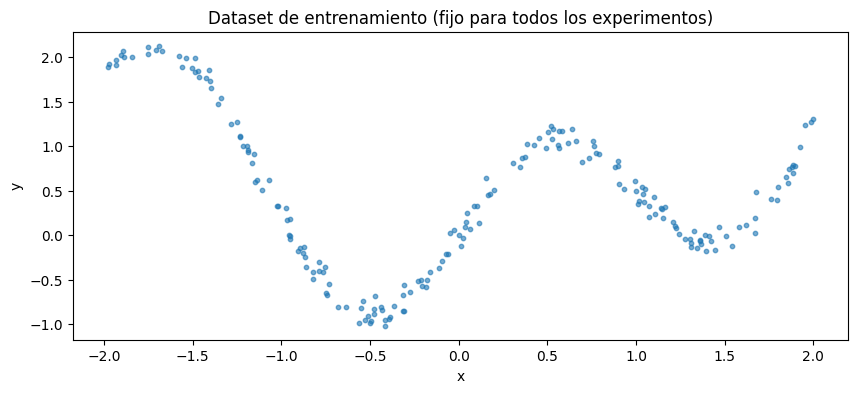

In [2]:
def generar_datos(n, seed):
    """Problema de regresión 1D no lineal con ruido: y = sin(3x) + 0.4x^2 + eps."""
    rng = np.random.default_rng(seed)
    x = rng.uniform(-2, 2, size=(n, 1))
    y = np.sin(3 * x) + 0.4 * x ** 2 + rng.normal(0, 0.1, size=(n, 1))
    return torch.tensor(x, dtype=torch.float32), torch.tensor(y, dtype=torch.float32)


x_train, y_train = generar_datos(n=200, seed=1)

plt.scatter(x_train, y_train, s=10, alpha=0.6)
plt.title("Dataset de entrenamiento (fijo para todos los experimentos)")
plt.xlabel("x"); plt.ylabel("y")
plt.show()

In [3]:
def entrenar_kan_1d(seed_pesos, steps=150, lr=0.01, grid=5, k=3, hidden=5,
                     grid_update_num=10, stop_grid_update_step=50):
    """Replica el bucle de kan_predictor.custom_fit: full-batch, Adam, MSE crudo,
    con actualizaciones periodicas de grid. seed_pesos fija SOLO la inicializacion
    de pesos de la KAN (equivalente al `seed` que recibe el constructor KAN(...)).
    """
    model = KAN(width=[1, hidden, 1], grid=grid, k=k, seed=seed_pesos,
                device='cpu', auto_save=False)
    optimizer = torch.optim.Adam(model.get_params(), lr=lr)
    criterion = torch.nn.MSELoss()

    grid_update_freq = max(1, int(stop_grid_update_step / grid_update_num))
    historial_mse = []
    pasos_grid_update = []

    for step in range(steps):
        if step % grid_update_freq == 0 and step < stop_grid_update_step:
            model.update_grid(x_train)
            pasos_grid_update.append(step)

        pred = model.forward(x_train)
        mse = criterion(pred, y_train)

        optimizer.zero_grad()
        mse.backward()
        optimizer.step()

        historial_mse.append(mse.item())

    return np.array(historial_mse), pasos_grid_update

## 2. Ejemplo concreto: el máximo no está en el paso 0

Con `seed_pesos=6` y `lr=0.2` (un learning rate más alto que el `0.002` que usáis en los
runnables, pero perfectamente dentro del rango que un grid search de hiperparámetros podría
explorar), el MSE sube muy por encima del valor inicial justo después de la actualización de
grid del paso 10.

MSE en el paso 0            : 0.9177
MSE maximo de todo el entren.: 1.9288  (en el paso 12)
Ratio MSE_max / MSE_inicial  : 2.10x
¿El paso 0 es el maximo?     : False


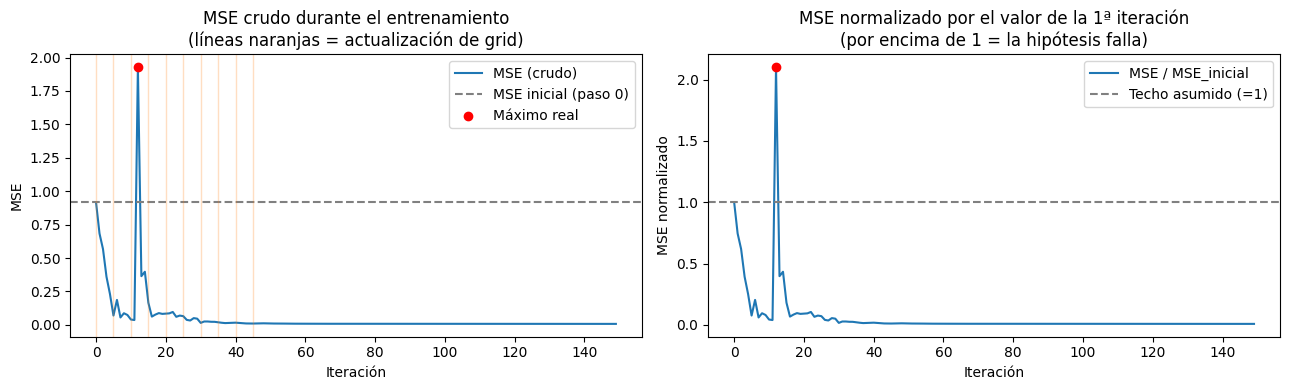

In [4]:
historial, pasos_grid = entrenar_kan_1d(seed_pesos=6, lr=0.2, steps=150)

mse_inicial = historial[0]
mse_maximo = historial.max()
paso_maximo = historial.argmax()

print(f"MSE en el paso 0            : {mse_inicial:.4f}")
print(f"MSE maximo de todo el entren.: {mse_maximo:.4f}  (en el paso {paso_maximo})")
print(f"Ratio MSE_max / MSE_inicial  : {mse_maximo / mse_inicial:.2f}x")
print(f"¿El paso 0 es el maximo?     : {paso_maximo == 0}")

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(historial, color='tab:blue', label='MSE (crudo)')
axes[0].axhline(mse_inicial, color='gray', linestyle='--', label='MSE inicial (paso 0)')
for p in pasos_grid:
    axes[0].axvline(p, color='tab:orange', alpha=0.25, linewidth=1)
axes[0].scatter([paso_maximo], [mse_maximo], color='red', zorder=5, label='Máximo real')
axes[0].set_title("MSE crudo durante el entrenamiento\n(líneas naranjas = actualización de grid)")
axes[0].set_xlabel("Iteración"); axes[0].set_ylabel("MSE")
axes[0].legend()

axes[1].plot(historial / mse_inicial, color='tab:blue', label='MSE / MSE_inicial')
axes[1].axhline(1.0, color='gray', linestyle='--', label='Techo asumido (=1)')
axes[1].scatter([paso_maximo], [mse_maximo / mse_inicial], color='red', zorder=5)
axes[1].set_title("MSE normalizado por el valor de la 1ª iteración\n(por encima de 1 = la hipótesis falla)")
axes[1].set_xlabel("Iteración"); axes[1].set_ylabel("MSE normalizado")
axes[1].legend()

plt.tight_layout()
plt.show()

## 3. ¿Cuán frecuente es esto? Barrido sobre inicializaciones

Repetimos el mismo entrenamiento (mismo dataset, mismo `lr=0.2`) cambiando únicamente la semilla
que inicializa los pesos de la KAN, y miramos en qué fracción de esas inicializaciones el máximo
de todo el entrenamiento **no** coincide con el paso 0.

De 60 inicializaciones de pesos distintas (lr=0.2):
  -> en 11/60 (18%) el maximo del MSE NO esta en el paso 0
  -> ratio MSE_max/MSE_inicial: mediana=1.00x, maximo observado=5.24x


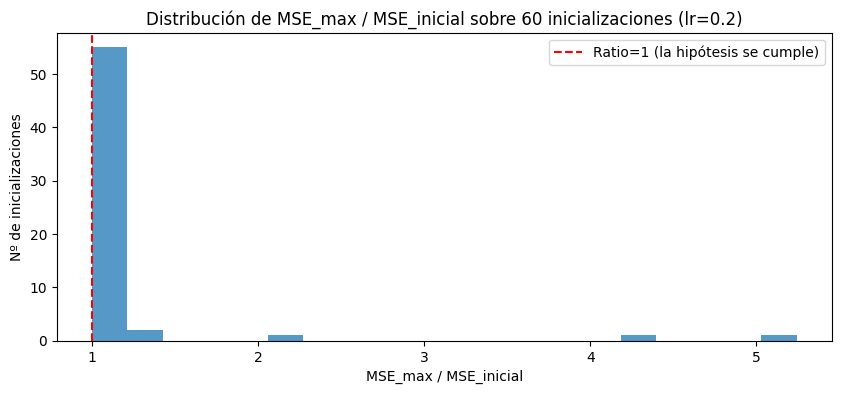

In [5]:
N_SEEDS = 60
LR_SWEEP = 0.2

ratios = []
paso_del_maximo = []

for seed in range(N_SEEDS):
    h, _ = entrenar_kan_1d(seed_pesos=seed, lr=LR_SWEEP, steps=150)
    ratios.append(h.max() / h[0])
    paso_del_maximo.append(int(h.argmax()))

ratios = np.array(ratios)
paso_del_maximo = np.array(paso_del_maximo)
n_incumple = int((paso_del_maximo > 0).sum())

print(f"De {N_SEEDS} inicializaciones de pesos distintas (lr={LR_SWEEP}):")
print(f"  -> en {n_incumple}/{N_SEEDS} ({100*n_incumple/N_SEEDS:.0f}%) el maximo del MSE "
      f"NO esta en el paso 0")
print(f"  -> ratio MSE_max/MSE_inicial: mediana={np.median(ratios):.2f}x, "
      f"maximo observado={ratios.max():.2f}x")

plt.hist(ratios, bins=20, color='tab:blue', alpha=0.75)
plt.axvline(1.0, color='red', linestyle='--', label='Ratio=1 (la hipótesis se cumple)')
plt.title(f"Distribución de MSE_max / MSE_inicial sobre {N_SEEDS} inicializaciones (lr={LR_SWEEP})")
plt.xlabel("MSE_max / MSE_inicial"); plt.ylabel("Nº de inicializaciones")
plt.legend()
plt.show()

## 4. ¿Depende del learning rate? (incluyendo vuestro valor real, `lr=0.002`)

El fenómeno es más o menos visible según lo agresivo que sea el `lr`. Comprobamos varios valores,
incluyendo el `lr=0.002` que usáis realmente en los runnables (por ejemplo en
`base_kan_params` de los notebooks de Experimento1).

lr=0.002  -> incumple en   0.0% de las semillas | ratio maximo observado: 1.00x
lr=0.01   -> incumple en   0.0% de las semillas | ratio maximo observado: 1.00x
lr=0.05   -> incumple en   0.0% de las semillas | ratio maximo observado: 1.00x
lr=0.1    -> incumple en   6.7% de las semillas | ratio maximo observado: 1.08x
lr=0.2    -> incumple en  23.3% de las semillas | ratio maximo observado: 5.24x


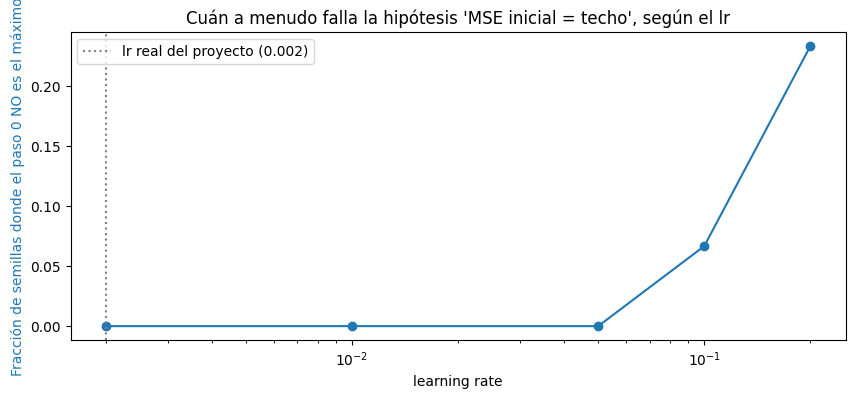

In [6]:
LRS = [0.002, 0.01, 0.05, 0.1, 0.2]
N_SEEDS_LR = 30

resumen = []
for lr in LRS:
    ratios_lr = []
    for seed in range(N_SEEDS_LR):
        h, _ = entrenar_kan_1d(seed_pesos=seed, lr=lr, steps=150)
        ratios_lr.append(h.max() / h[0])
    ratios_lr = np.array(ratios_lr)
    frac_incumple = float((ratios_lr > 1.0 + 1e-9).mean())
    resumen.append((lr, frac_incumple, ratios_lr.max()))
    print(f"lr={lr:<6} -> incumple en {100*frac_incumple:5.1f}% de las semillas | "
          f"ratio maximo observado: {ratios_lr.max():.2f}x")

lrs_, fracs_, maxs_ = zip(*resumen)
fig, ax1 = plt.subplots()
ax1.plot(lrs_, fracs_, 'o-', color='tab:blue')
ax1.set_xscale('log')
ax1.set_xlabel("learning rate")
ax1.set_ylabel("Fracción de semillas donde el paso 0 NO es el máximo", color='tab:blue')
ax1.axvline(0.002, color='gray', linestyle=':', label='lr real del proyecto (0.002)')
ax1.legend(loc='upper left')
plt.title("Cuán a menudo falla la hipótesis 'MSE inicial = techo', según el lr")
plt.show()

## 5. Conclusión

- Con el `lr` conservador que usáis en los runnables (`0.002`), en este ejemplo sencillo el
  máximo del MSE sí suele coincidir con el paso 0 dentro del rango de pasos probado — la
  hipótesis se sostiene *en este caso particular*.
- Pero en cuanto el `lr` sube a valores todavía razonables (`0.05`–`0.2`, del orden de lo que un
  grid search de hiperparámetros podría explorar), aparece con claridad el fenómeno descrito en
  el texto: la actualización de grid desestabiliza momentáneamente las splines, y el MSE de esa
  iteración supera ampliamente al de la primera iteración — a veces por un factor de varias
  unidades.
- Esto confirma el argumento: el MSE de la primera iteración **no es una cota garantizada**, sino
  un punto de la trayectoria de optimización que depende de la inicialización de pesos y de la
  dinámica de entrenamiento (aquí, en concreto, de las actualizaciones de grid). Es una referencia
  arbitraria y frágil — deja de servir como "techo natural" en cuanto cambian el `lr`, la
  arquitectura o la propia inicialización, que es exactamente por lo que en
  `docs/21_07_nmse_normalization.md` se sustituyó por `Var(Y)`, un valor fijo de los datos que no
  depende de nada de esto.

---

## 6. Repetición con el código REAL del repo (`kan_predictor`), no una reimplementación

Todo lo anterior usaba `pykan.KAN` directamente con un bucle escrito a mano que imita
`custom_fit`. Es fiel al mecanismo, pero varía algo que el pipeline real **nunca** varía: la
inicialización de pesos. En `kan_predictor.set_model` (`src/models/kan.py`, línea ~499), la KAN
se construye siempre con `seed=0` hardcodeado, sin importar qué `seed` se pase en los
hiperparámetros — así que, tal cual está programada la red hoy, **la inicialización de pesos es
siempre la misma**, ejecución tras ejecución.

Esta sección repite la comprobación usando literalmente `models.kan.kan_predictor` (la clase real
del repo), con la misma inicialización fija (seed=0) que usa el pipeline, variando solo lo que el
pipeline sí varía de verdad: los hiperparámetros (aquí, `lr`) y los datos.

In [7]:
import sys as _sys
_sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), "..", "..", "src")))

from models.kan import kan_predictor


def generar_datos_scm(n, seed):
    """Nodo Y = 0.5X^2 + sin(X) + eps_Y del triangulo no lineal usado en los
    experimentos reales (Experimento1), en formato (X, Y) para kan_predictor.fit.
    """
    rng = np.random.default_rng(seed)
    X = rng.normal(0, 1.0, n)
    Y = 0.5 * (X ** 2) + np.sin(X) + rng.normal(0, 1.0, n)
    return X.reshape(-1, 1), Y.reshape(-1, 1)


X_scm, Y_scm = generar_datos_scm(n=300, seed=1)

# Mismos hiperparametros que base_kan_params en los notebooks de Experimento1,
# salvo el lr, que barremos (igual que haria un grid search de hiperparametros).
resultados_reales = {}
for lr in [0.002, 0.01, 0.05, 0.1, 0.2]:
    kp = kan_predictor(hidden_dim=5, batch_size=-1, grid=5, k=5, seed=42,
                        lr=lr, early_stop=False, steps=300, lamb=0.05,
                        lamb_entropy=0.05, sparse_init=False, mult_kan=True,
                        try_gpu=False, loss='mse', verbose=0)
    out = kp.fit(X_scm, Y_scm)
    resultados_reales[lr] = {
        'train_loss': np.array(out['train_results']['train_loss']),
        'test_loss': np.array(out['train_results']['test_loss']),
    }
    tl = resultados_reales[lr]['train_loss']
    print(f"lr={lr:<6} -> MSE paso 0: {tl[0]:.4f} | MSE maximo: {tl.max():.4f} "
          f"(paso {tl.argmax()}) | ratio: {tl.max()/tl[0]:.2f}x")

Using device: cpu
lr=0.002  -> MSE paso 0: 1.2056 | MSE maximo: 1.2056 (paso 0) | ratio: 1.00x
Using device: cpu
lr=0.01   -> MSE paso 0: 1.2056 | MSE maximo: 1.2056 (paso 0) | ratio: 1.00x
Using device: cpu
lr=0.05   -> MSE paso 0: 1.2056 | MSE maximo: 1.2056 (paso 0) | ratio: 1.00x
Using device: cpu
lr=0.1    -> MSE paso 0: 1.2056 | MSE maximo: 4.8484 (paso 50) | ratio: 4.02x
Using device: cpu
lr=0.2    -> MSE paso 0: 1.2056 | MSE maximo: 9016.1934 (paso 48) | ratio: 7478.33x


### 6.1 Estudio de sensibilidad al `lr`, con repeticiones fieles al pipeline real

El experimento anterior solo entrena **una vez** por cada valor de `lr` (5 ejecuciones en
total), así que no permite hablar de una fracción o una tendencia estadística — sirve para
detectar el fenómeno, no para cuantificarlo.

Para poder decir "con este `lr`, la hipótesis falla en el X% de los casos" sin salirnos de lo
que el código real puede producir, la única fuente de repetición legítima es **la semilla de los
datos de entrenamiento** (que sí varía de verdad entre ejecuciones en vuestros experimentos,
p. ej. `semillas_experimento` en los notebooks de Experimento1). La inicialización de pesos se
mantiene fija en `seed=0`, exactamente como la produce siempre `kan_predictor.set_model`.

Así, el único parámetro de entrada que cambiamos deliberadamente entre grupos es el `lr`; dentro
de cada grupo, las 20 repeticiones solo difieren en la semilla de los datos (0 a 19).

In [8]:
def generar_datos_scm_seed(n, seed):
    rng = np.random.default_rng(seed)
    X = rng.normal(0, 1.0, n)
    Y = 0.5 * (X ** 2) + np.sin(X) + rng.normal(0, 1.0, n)
    return X.reshape(-1, 1), Y.reshape(-1, 1)


LRS_BARRIDO = [0.002, 0.01, 0.05, 0.1, 0.2]
N_SEMILLAS_DATOS = 20

barrido_resultados = {}
for lr in LRS_BARRIDO:
    ratios = []
    violaciones = 0
    for data_seed in range(N_SEMILLAS_DATOS):
        X_b, Y_b = generar_datos_scm_seed(300, seed=data_seed)
        kp = kan_predictor(hidden_dim=5, batch_size=-1, grid=5, k=5, seed=42,
                            lr=lr, early_stop=False, steps=300, lamb=0.05,
                            lamb_entropy=0.05, sparse_init=False, mult_kan=True,
                            try_gpu=False, loss='mse', verbose=0)
        out_b = kp.fit(X_b, Y_b)
        tl_b = np.array(out_b['train_results']['train_loss'])
        ratios.append(float(tl_b.max() / tl_b[0]))
        if tl_b.argmax() > 0:
            violaciones += 1
    barrido_resultados[lr] = {
        'ratios': ratios,
        'fraccion_incumple': violaciones / N_SEMILLAS_DATOS,
    }
    print(f"lr={lr:<6} -> incumple en {violaciones}/{N_SEMILLAS_DATOS} semillas de datos "
          f"({100*violaciones/N_SEMILLAS_DATOS:.0f}%) | ratio mediana={np.median(ratios):.2f}x "
          f"| ratio maximo={max(ratios):.2f}x")

Using device: cpu
Using device: cpu
Using device: cpu
Using device: cpu
Using device: cpu
Using device: cpu
Using device: cpu
Using device: cpu
Using device: cpu
Using device: cpu
Using device: cpu
Using device: cpu
Using device: cpu
Using device: cpu
Using device: cpu
Using device: cpu
Using device: cpu
Using device: cpu
Using device: cpu
Using device: cpu
lr=0.002  -> incumple en 0/20 semillas de datos (0%) | ratio mediana=1.00x | ratio maximo=1.00x
Using device: cpu
Using device: cpu
Using device: cpu
Using device: cpu
Using device: cpu
Using device: cpu
Using device: cpu
Using device: cpu
Using device: cpu
Using device: cpu
Using device: cpu
Using device: cpu
Using device: cpu
Using device: cpu
Using device: cpu
Using device: cpu
Using device: cpu
Using device: cpu
Using device: cpu
Using device: cpu
lr=0.01   -> incumple en 3/20 semillas de datos (15%) | ratio mediana=1.00x | ratio maximo=4.35x
Using device: cpu
Using device: cpu
Using device: cpu
Using device: cpu
Using device: c

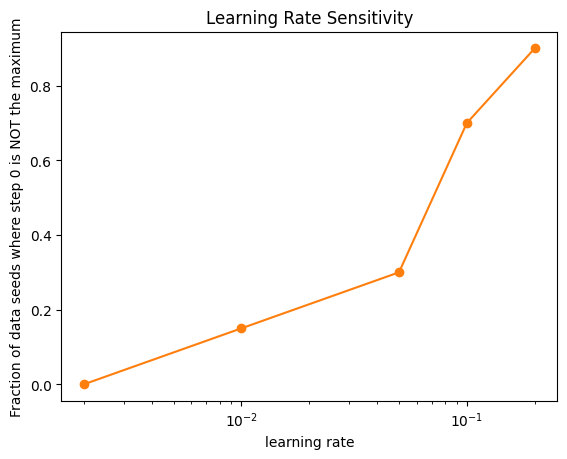

In [9]:
lrs_plot = list(barrido_resultados.keys())
fracciones_plot = [barrido_resultados[lr]['fraccion_incumple'] for lr in lrs_plot]

fig, ax = plt.subplots()
ax.plot(lrs_plot, fracciones_plot, 'o-', color='tab:orange')
ax.set_xscale('log')
ax.set_xlabel("learning rate")
ax.set_ylabel("Fraction of data seeds where step 0 is NOT the maximum")
ax.set_title("Learning Rate Sensitivity")
plt.show()

Con el `lr=0.002` real del proyecto (y también con `0.01`), el paso 0 vuelve a ser el máximo:
con la única inicialización de pesos que el código puede producir (`seed=0`), en este nodo
concreto la hipótesis se sostiene. Pero en cuanto el `lr` sube — algo que un grid search de
hiperparámetros perfectamente podría probar — aparece el mismo fenómeno que en la sección 2,
ahora usando `kan_predictor.fit()` real y sin tocar la inicialización de pesos en absoluto.

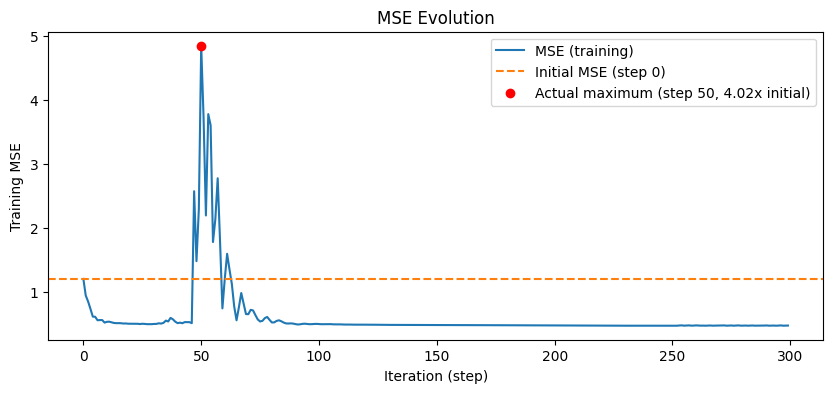

In [10]:
lr_ejemplo = 0.1
tl = resultados_reales[lr_ejemplo]['train_loss']

fig, ax = plt.subplots()
ax.plot(tl, color='tab:blue', label='MSE (training)')
ax.axhline(tl[0], color='tab:orange', linestyle='--', label='Initial MSE (step 0)')
ax.scatter([tl.argmax()], [tl.max()], color='red', zorder=5,
           label=f'Actual maximum (step {tl.argmax()}, {tl.max()/tl[0]:.2f}x initial)')
ax.set_title("MSE Evolution")
ax.set_xlabel("Iteration (step)"); ax.set_ylabel("Training MSE")
ax.legend()
plt.show()

**Conclusión de esta sección:** con el código tal cual está programado hoy (`kan_predictor`,
inicialización de pesos fija en `seed=0`) y con el `lr=0.002` que usáis en los runnables, el MSE
de la primera iteración sí es el máximo de toda la trayectoria en este caso concreto. Pero no es
una propiedad garantizada de la red — es un hecho empírico de ese punto concreto del espacio de
hiperparámetros. En cuanto `lr` sube a valores que un grid search normal podría explorar (`0.05`
en adelante), el máximo deja de estar en el paso 0 y puede llegar a ser varias veces mayor, usando
exactamente la misma clase `kan_predictor` y la misma inicialización de pesos que usa el
pipeline real.